In [3]:
import os
import platform
from datetime import datetime

os_info = f"{platform.system()} {platform.release()}"
timestamp = datetime.now().strftime("%d-%m-%Y %H:%M:%S")

print(f"Current OS: {os_info}")
print(f"Log Timestamp: {timestamp}")

Current OS: Linux 6.17.0-22-generic
Log Timestamp: 24-03-2026 19:36:50


# **Experiment 4: Data Analytics I**
**Objective:** Create a Linear Regression Model to predict home prices using the Boston Housing Dataset.

**Dataset Details:** 
- Total Samples: 506
- Features: 13 input variables (CRIM, ZN, INDUS, etc.)
- Target: MEDV (Median value of owner-occupied homes in $1000s)

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

dataset_path = os.path.join("datasets", "BostonHousingData.csv")
df = pd.read_csv(dataset_path)

print(f"Dataset Shape: {df.shape}")
print(df.head())


Dataset Shape: (506, 14)
      CRIM    ZN  INDUS  CHAS    NOX     RM   AGE     DIS  RAD  TAX  PTRATIO  \
0  0.00632  18.0   2.31   0.0  0.538  6.575  65.2  4.0900    1  296     15.3   
1  0.02731   0.0   7.07   0.0  0.469  6.421  78.9  4.9671    2  242     17.8   
2  0.02729   0.0   7.07   0.0  0.469  7.185  61.1  4.9671    2  242     17.8   
3  0.03237   0.0   2.18   0.0  0.458  6.998  45.8  6.0622    3  222     18.7   
4  0.06905   0.0   2.18   0.0  0.458  7.147  54.2  6.0622    3  222     18.7   

        B  LSTAT  MEDV  
0  396.90   4.98  24.0  
1  396.90   9.14  21.6  
2  392.83   4.03  34.7  
3  394.63   2.94  33.4  
4  396.90    NaN  36.2  


### Data Preprocessing & Exploratory Data Analysis (EDA)
Before running the booster (model), we need to check for null values and understand feature correlations.

Missing values count:
 CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
PRICE      0
dtype: int64


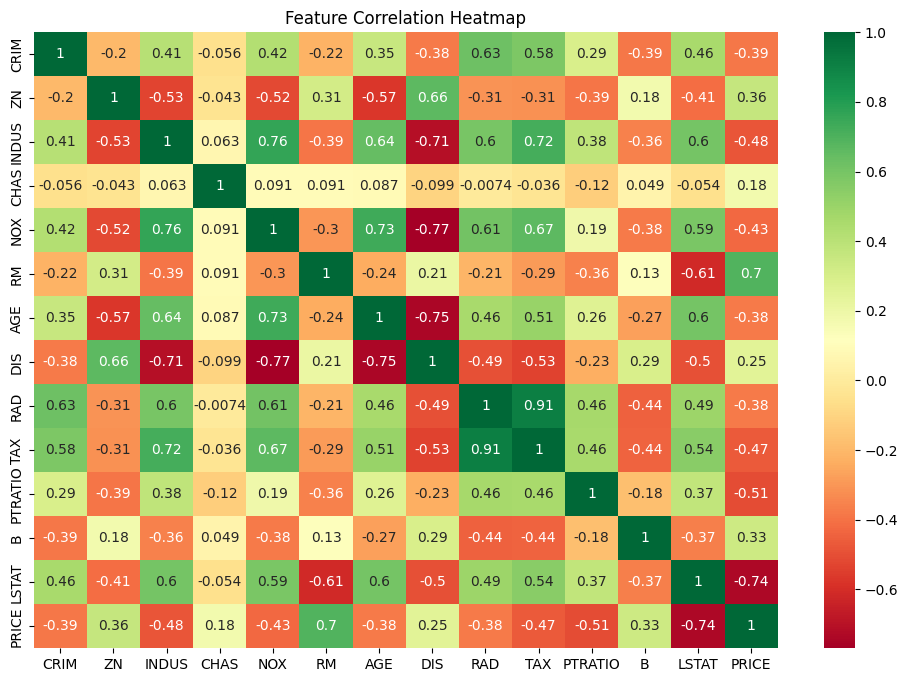

In [ ]:
print("Missing values count:\n", df.isnull().sum())

plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, cmap='RdYlGn')
plt.title("Feature Correlation Heatmap")
plt.show()


### Model Training
We will split the data into training and testing sets (80/20 split) and initialize the `LinearRegression` engine.

In [ ]:
X = df.drop('PRICE', axis=1)
y = df['PRICE']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


### Performance Evaluation
Metrics to measure efficiency: 
1. **RMSE** (Root Mean Squared Error)
2. **R² Score** (Coefficient of Determination)

Regression Performance:
-> RMSE: 4.93
-> R2 Score: 0.67


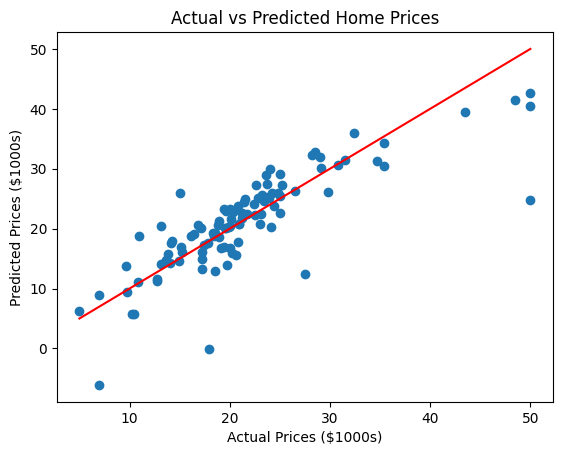

In [ ]:
y_pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"Regression Performance:")
print(f"-> RMSE: {rmse:.2f}")
print(f"-> R2 Score: {r2:.2f}")

plt.scatter(y_test, y_pred)
plt.xlabel("Actual Prices ($1000s)")
plt.ylabel("Predicted Prices ($1000s)")
plt.title("Actual vs Predicted Home Prices")
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red')
plt.show()
